In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import statsmodels.formula.api as smf
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.grid': True, 'grid.alpha': 0.3})

FIGURE_DIR = './figures/nb07'
os.makedirs(FIGURE_DIR, exist_ok=True)

# %%
panel = pd.read_parquet('./data/panel_ca_daily_v2.parquet')
panel['date'] = pd.to_datetime(panel['date'])
panel['community_area'] = panel['community_area'].astype(str)
print(f"Panel: {panel.shape[0]:,} x {panel.shape[1]}")

# Compute 2019 crime mean per community (basis for all percentile splits)
ca_crime_2019 = (panel[panel['year'] == 2019]
                 .groupby('community_area')['crime_total']
                 .mean()
                 .sort_values(ascending=False))

print(f"\n2019 daily crime mean per community:")
print(f"  Min:    {ca_crime_2019.min():.2f}")
print(f"  Median: {ca_crime_2019.median():.2f}")
print(f"  Max:    {ca_crime_2019.max():.2f}")
print(f"  Communities: {len(ca_crime_2019)}")

Panel: 703,087 x 59

2019 daily crime mean per community:
  Min:    0.73
  Median: 6.07
  Max:    40.30
  Communities: 77


In [2]:
# 1. Define All Grouping Methods

def make_percentile_groups(ca_series, top_pct, bottom_pct):
    """Split communities by top/bottom percentile of 2019 crime."""
    top_threshold = ca_series.quantile(1 - top_pct)
    bottom_threshold = ca_series.quantile(bottom_pct)
    high = set(ca_series[ca_series >= top_threshold].index)
    low = set(ca_series[ca_series <= bottom_threshold].index)
    # Remove overlap if thresholds coincide
    low = low - high
    return high, low

# Define all 7 binary grouping methods
groupings = {}

# 1. LISA HH vs LL (original)
hh_cas = set(panel[panel['lisa_cluster'] == 'HH']['community_area'].unique())
ll_cas = set(panel[panel['lisa_cluster'] == 'LL']['community_area'].unique())
groupings['LISA HH vs LL'] = (hh_cas, ll_cas)

# 2-6. Percentile splits
for label, top_pct, bot_pct in [
    ('Top 10% vs Bot 10%', 0.10, 0.10),
    ('Top 20% vs Bot 20%', 0.20, 0.20),
    ('Top 25% vs Bot 25%', 0.25, 0.25),
    ('Top 33% vs Bot 33%', 0.33, 0.33),
    ('Median Split', 0.50, 0.50),
]:
    high, low = make_percentile_groups(ca_crime_2019, top_pct, bot_pct)
    groupings[label] = (high, low)

# 7. Top 10% vs Middle 80%
top10, _ = make_percentile_groups(ca_crime_2019, 0.10, 0.10)
_, bot10 = make_percentile_groups(ca_crime_2019, 0.10, 0.10)
middle80 = set(ca_crime_2019.index) - top10 - bot10
groupings['Top 10% vs Mid 80%'] = (top10, middle80)

# Print summary
print(f"{'Grouping':<25s} {'High':>6s} {'Low':>6s} {'Total':>7s} {'% of 77':>8s}")
print("-" * 55)
for label, (high, low) in groupings.items():
    total = len(high) + len(low)
    pct = total / 77 * 100
    print(f"  {label:<23s} {len(high):>6d} {len(low):>6d} {total:>7d} {pct:>7.1f}%")


Grouping                    High    Low   Total  % of 77
-------------------------------------------------------
  LISA HH vs LL               11      2      13    16.9%
  Top 10% vs Bot 10%           8      8      16    20.8%
  Top 20% vs Bot 20%          16     16      32    41.6%
  Top 25% vs Bot 25%          20     20      40    51.9%
  Top 33% vs Bot 33%          26     26      52    67.5%
  Median Split                39     38      77   100.0%
  Top 10% vs Mid 80%           8     61      69    89.6%


In [3]:
# 2. Run DID for All Groupings × All Crime Types

y_variables = [
    ('crime_total', 'Total Crime'),
    ('crime_violent', 'Violent Crime'),
    ('crime_property', 'Property Crime'),
    ('crime_theft', 'Theft'),
    ('crime_battery', 'Battery'),
    ('crime_homicide', 'Homicide'),
    ('crime_burglary', 'Burglary'),
    ('crime_mvt', 'Motor Vehicle Theft'),
    ('crime_narcotics', 'Narcotics'),
    ('crime_robbery', 'Robbery'),
    ('crime_assault', 'Assault'),
    ('arrest_count', 'Arrests'),
    ('domestic_count', 'Domestic Crime'),
]

controls = 'temp_mean + precipitation + is_weekend + is_holiday'
all_results = []

for g_label, (high_set, low_set) in groupings.items():
    # Filter panel to selected communities, years 2019-2020
    sample = panel[
        (panel['community_area'].isin(high_set | low_set)) &
        (panel['year'].isin([2019, 2020]))
    ].copy()

    sample['post'] = (sample['date'] >= '2020-03-21').astype(int)
    sample['treated'] = sample['community_area'].isin(high_set).astype(int)
    sample['did'] = sample['post'] * sample['treated']

    for y_col, y_label in y_variables:
        formula = f'{y_col} ~ post + did + {controls} + C(community_area)'

        try:
            model = smf.ols(formula, data=sample).fit(
                cov_type='cluster',
                cov_kwds={'groups': sample['community_area']}
            )
            coef = model.params['did']
            se = model.bse['did']
            p = model.pvalues['did']
        except Exception as e:
            coef, se, p = np.nan, np.nan, np.nan

        all_results.append({
            'grouping': g_label,
            'y_var': y_col,
            'y_label': y_label,
            'coef': coef,
            'se': se,
            'p': p,
            'n_high': len(high_set),
            'n_low': len(low_set),
            'n_obs': len(sample),
        })

    print(f"  {g_label}: done ({len(sample):,} obs)")

results_df = pd.DataFrame(all_results)
print(f"\nTotal regressions: {len(results_df)}")

  LISA HH vs LL: done (9,503 obs)
  Top 10% vs Bot 10%: done (11,696 obs)
  Top 20% vs Bot 20%: done (23,392 obs)
  Top 25% vs Bot 25%: done (29,240 obs)
  Top 33% vs Bot 33%: done (38,012 obs)
  Median Split: done (56,287 obs)
  Top 10% vs Mid 80%: done (50,439 obs)

Total regressions: 91


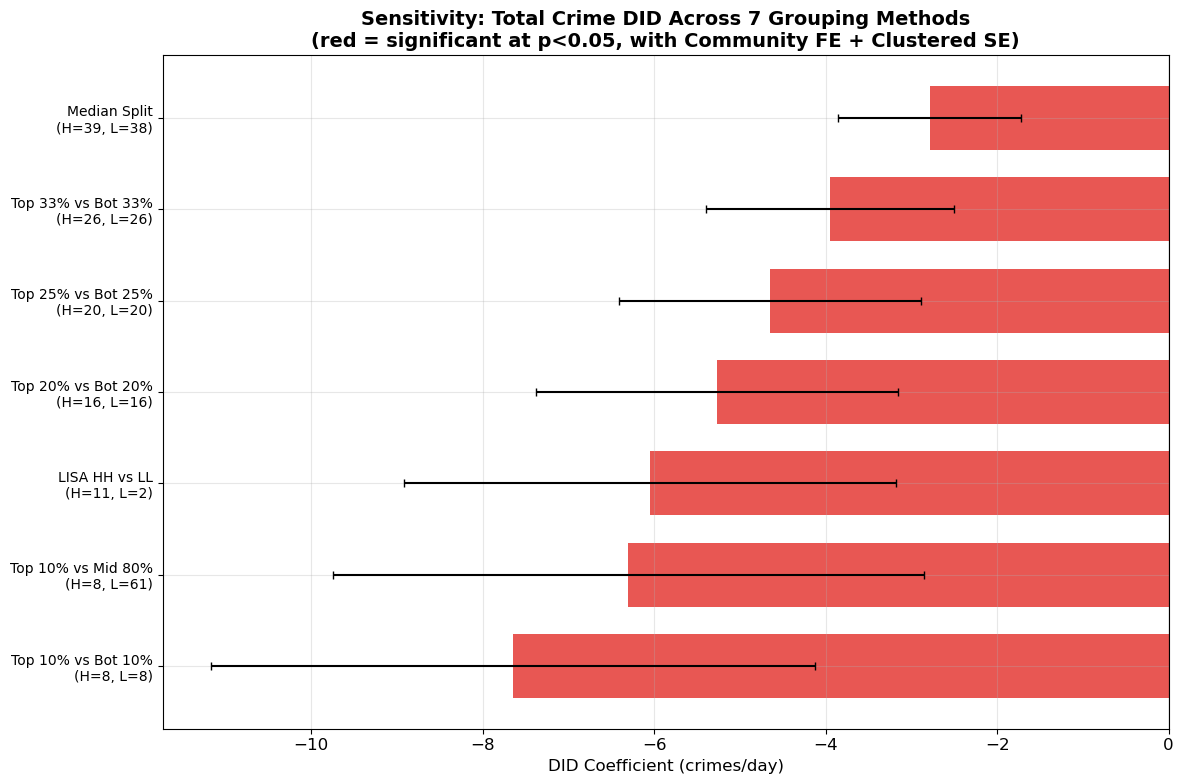


Grouping                      Coef       SE        p   Sig    H    L
-----------------------------------------------------------------
  Top 10% vs Bot 10%        -7.650    1.796   0.0000   ***    8    8
  Top 10% vs Mid 80%        -6.303    1.758   0.0003   ***    8   61
  LISA HH vs LL             -6.047    1.462   0.0000   ***   11    2
  Top 20% vs Bot 20%        -5.272    1.077   0.0000   ***   16   16
  Top 25% vs Bot 25%        -4.648    0.898   0.0000   ***   20   20
  Top 33% vs Bot 33%        -3.949    0.740   0.0000   ***   26   26
  Median Split              -2.788    0.544   0.0000   ***   39   38


In [4]:
# 3. Results: Total Crime DID Across Groupings

total_crime = results_df[results_df['y_var'] == 'crime_total'].copy()
total_crime = total_crime.sort_values('n_high', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#E53935' if p < 0.05 else '#BDBDBD' for p in total_crime['p']]
y_pos = range(len(total_crime))

ax.barh(y_pos, total_crime['coef'], xerr=1.96*total_crime['se'],
        color=colors, capsize=3, alpha=0.85, height=0.7)

labels = [f"{row['grouping']}\n(H={row['n_high']}, L={row['n_low']})"
          for _, row in total_crime.iterrows()]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('DID Coefficient (crimes/day)')
ax.set_title('Sensitivity: Total Crime DID Across 7 Grouping Methods\n'
             '(red = significant at p<0.05, with Community FE + Clustered SE)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_sensitivity_total_crime.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print table
print(f"\n{'Grouping':<25s} {'Coef':>8s} {'SE':>8s} {'p':>8s} {'Sig':>5s} {'H':>4s} {'L':>4s}")
print("-" * 65)
for _, r in total_crime.iterrows():
    sig = '***' if r['p']<0.001 else ('**' if r['p']<0.01 else ('*' if r['p']<0.05 else ''))
    print(f"  {r['grouping']:<23s} {r['coef']:>+8.3f} {r['se']:>8.3f} {r['p']:>8.4f} {sig:>5s} {r['n_high']:>4.0f} {r['n_low']:>4.0f}")


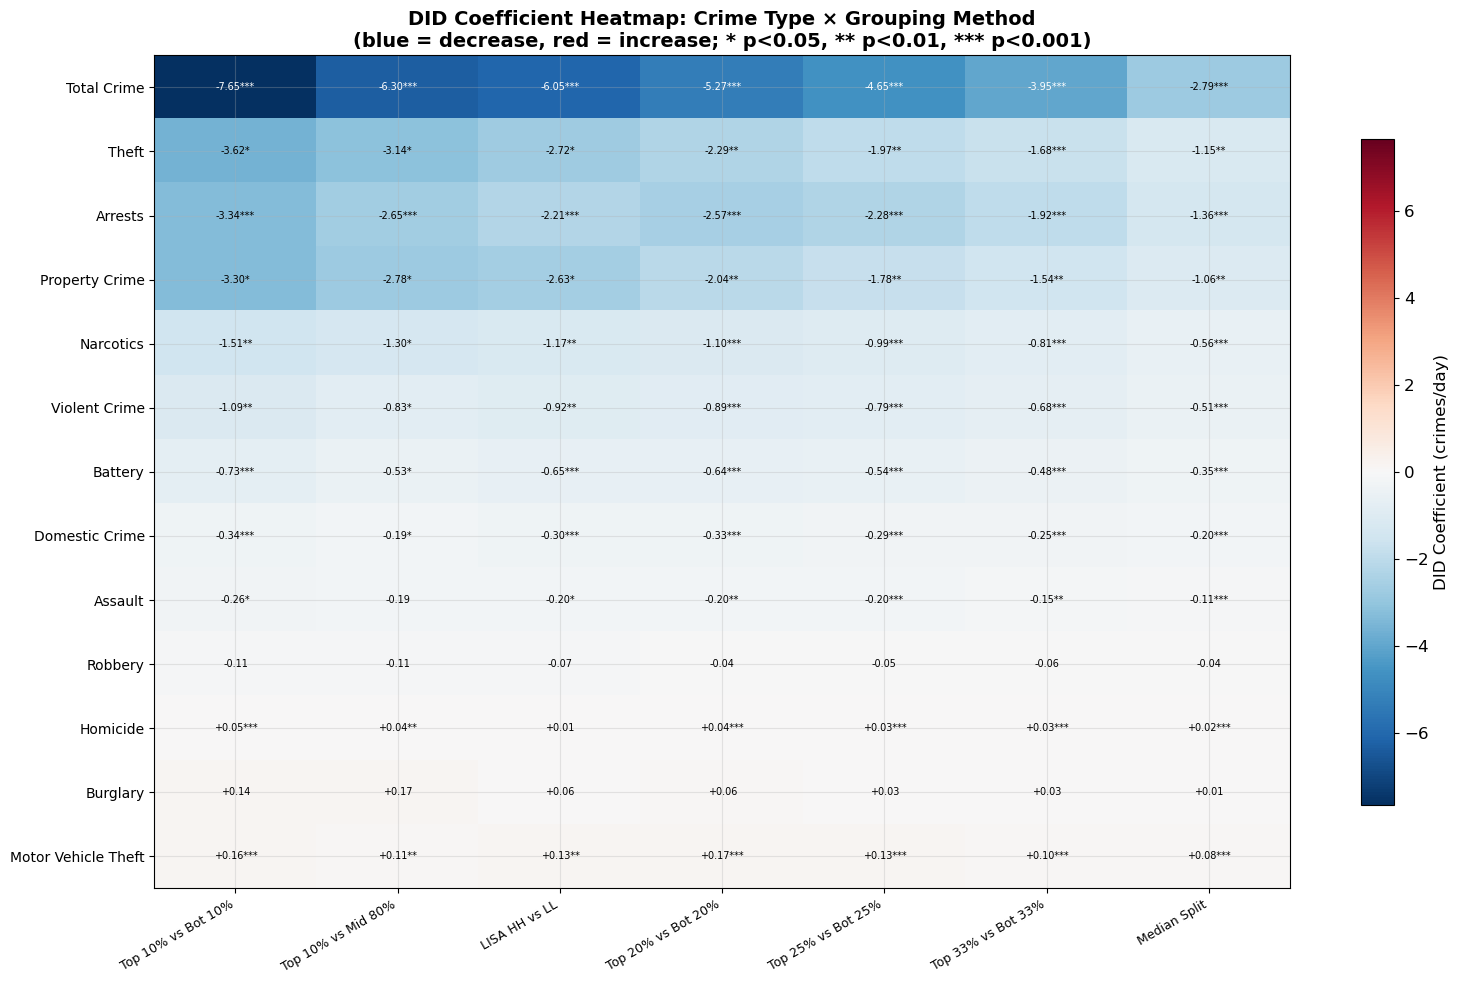

In [5]:
# 4. Heatmap: All Groupings × All Crime Types

# Pivot: rows = crime types, columns = groupings, values = DID coefficient
coef_pivot = results_df.pivot(index='y_label', columns='grouping', values='coef')
p_pivot = results_df.pivot(index='y_label', columns='grouping', values='p')

# Order columns by number of communities used (narrow to wide)
col_order = total_crime.sort_values('n_high')['grouping'].tolist()
coef_pivot = coef_pivot[col_order]
p_pivot = p_pivot[col_order]

# Order rows by average coefficient
row_order = coef_pivot.mean(axis=1).sort_values().index.tolist()
coef_pivot = coef_pivot.loc[row_order]
p_pivot = p_pivot.loc[row_order]

fig, ax = plt.subplots(figsize=(16, 10))

# Plot heatmap
vmax = max(abs(coef_pivot.values.min()), abs(coef_pivot.values.max()))
im = ax.imshow(coef_pivot.values, cmap='RdBu_r', aspect='auto',
               vmin=-vmax, vmax=vmax)

# Add text annotations with significance markers
for i in range(len(coef_pivot.index)):
    for j in range(len(coef_pivot.columns)):
        coef_val = coef_pivot.values[i, j]
        p_val = p_pivot.values[i, j]
        if np.isnan(coef_val):
            continue
        sig = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        text = f'{coef_val:+.2f}{sig}'
        text_color = 'white' if abs(coef_val) > vmax * 0.5 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=7, color=text_color)

ax.set_xticks(range(len(coef_pivot.columns)))
ax.set_xticklabels(coef_pivot.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(coef_pivot.index)))
ax.set_yticklabels(coef_pivot.index, fontsize=10)
ax.set_title('DID Coefficient Heatmap: Crime Type × Grouping Method\n'
             '(blue = decrease, red = increase; * p<0.05, ** p<0.01, *** p<0.001)',
             fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='DID Coefficient (crimes/day)', shrink=0.8)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_sensitivity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# 5. Continuous Treatment Intensity

# Instead of binary High/Low split, use each community's 2019 crime mean as a continuous treatment intensity measure. This uses ALL 77
# communities with NO arbitrary cutoff.
# Model: Y_it = α_i + β₁·Post_t + β₃·Post_t × CrimeMean_i + X_it·γ + ε_it
# β₃ interprets as: "for each additional crime/day in 2019 baseline,
# how much more did crime change after COVID?"

cont_sample = panel[panel['year'].isin([2019, 2020])].copy()
cont_sample['post'] = (cont_sample['date'] >= '2020-03-21').astype(int)
cont_sample['crime_mean_2019'] = cont_sample['community_area'].map(ca_crime_2019)
cont_sample['post_x_intensity'] = cont_sample['post'] * cont_sample['crime_mean_2019']

print("Continuous Treatment Intensity (all 77 communities):")
print(f"  N observations: {len(cont_sample):,}")
print(f"  Crime mean 2019 range: [{ca_crime_2019.min():.2f}, {ca_crime_2019.max():.2f}]")

cont_results = []
print(f"\n{'Y Variable':<25s} {'β(Post×Intensity)':>18s} {'SE':>8s} {'p':>10s} {'Sig':>5s}")
print("-" * 70)

for y_col, y_label in y_variables:
    formula = f'{y_col} ~ post + post_x_intensity + {controls} + C(community_area)'
    model = smf.ols(formula, data=cont_sample).fit(
        cov_type='cluster',
        cov_kwds={'groups': cont_sample['community_area']}
    )

    coef = model.params['post_x_intensity']
    se = model.bse['post_x_intensity']
    p = model.pvalues['post_x_intensity']
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))

    cont_results.append({'y_label': y_label, 'coef': coef, 'se': se, 'p': p})
    print(f"  {y_label:<23s} {coef:>+18.4f} {se:>8.4f} {p:>10.4f} {sig:>5s}")

print(f"\nInterpretation: A community with 10 more crimes/day in 2019 baseline")
print(f"experienced an additional {cont_results[0]['coef']*10:+.2f} crimes/day change after COVID")


Continuous Treatment Intensity (all 77 communities):
  N observations: 56,287
  Crime mean 2019 range: [0.73, 40.30]

Y Variable                 β(Post×Intensity)       SE          p   Sig
----------------------------------------------------------------------
  Total Crime                        -0.2750   0.0579     0.0000   ***
  Violent Crime                      -0.0441   0.0121     0.0003   ***
  Property Crime                     -0.1182   0.0435     0.0066    **
  Theft                              -0.1313   0.0442     0.0030    **
  Battery                            -0.0300   0.0064     0.0000   ***
  Homicide                           +0.0019   0.0005     0.0001   ***
  Burglary                           +0.0050   0.0049     0.3117      
  Motor Vehicle Theft                +0.0064   0.0015     0.0000   ***
  Narcotics                          -0.0516   0.0151     0.0006   ***
  Robbery                            -0.0041   0.0027     0.1234      
  Assault                     

In [7]:
# 6. Placebo Tests Across Groupings

# Run placebo (fake COVID in March 2018) for each grouping method. If placebo fails only for LISA but passes for other groupings,
# the problem is LISA-specific, not a fundamental DID issue.

placebo_results = []

for g_label, (high_set, low_set) in groupings.items():
    placebo = panel[
        (panel['community_area'].isin(high_set | low_set)) &
        (panel['year'].isin([2017, 2018]))
    ].copy()

    placebo['post'] = (placebo['date'] >= '2018-03-21').astype(int)
    placebo['treated'] = placebo['community_area'].isin(high_set).astype(int)
    placebo['did'] = placebo['post'] * placebo['treated']

    try:
        mod = smf.ols(
            f'crime_total ~ post + did + {controls} + C(community_area)',
            data=placebo
        ).fit(cov_type='cluster', cov_kwds={'groups': placebo['community_area']})

        placebo_results.append({
            'grouping': g_label,
            'coef': mod.params['did'],
            'se': mod.bse['did'],
            'p': mod.pvalues['did'],
            'pass': mod.pvalues['did'] > 0.05
        })
    except:
        placebo_results.append({
            'grouping': g_label, 'coef': np.nan, 'se': np.nan, 'p': np.nan, 'pass': None
        })

placebo_df = pd.DataFrame(placebo_results)

print(f"\n{'Grouping':<25s} {'Placebo Coef':>12s} {'p-value':>10s} {'Result':>10s}")
print("-" * 60)
for _, r in placebo_df.iterrows():
    result = 'PASS' if r['pass'] else 'FAIL'
    color = '' if r['pass'] else ' !!!'
    print(f"  {r['grouping']:<23s} {r['coef']:>+12.3f} {r['p']:>10.4f} {result:>10s}{color}")

n_pass = placebo_df['pass'].sum()
n_total = len(placebo_df)
print(f"\nPlacebo pass rate: {n_pass}/{n_total}")



Grouping                  Placebo Coef    p-value     Result
------------------------------------------------------------
  LISA HH vs LL                 +1.238     0.0003       FAIL !!!
  Top 10% vs Bot 10%            +1.733     0.0000       FAIL !!!
  Top 20% vs Bot 20%            +1.428     0.0000       FAIL !!!
  Top 25% vs Bot 25%            +1.207     0.0000       FAIL !!!
  Top 33% vs Bot 33%            +0.985     0.0000       FAIL !!!
  Median Split                  +0.698     0.0000       FAIL !!!
  Top 10% vs Mid 80%            +1.462     0.0000       FAIL !!!

Placebo pass rate: 0/7


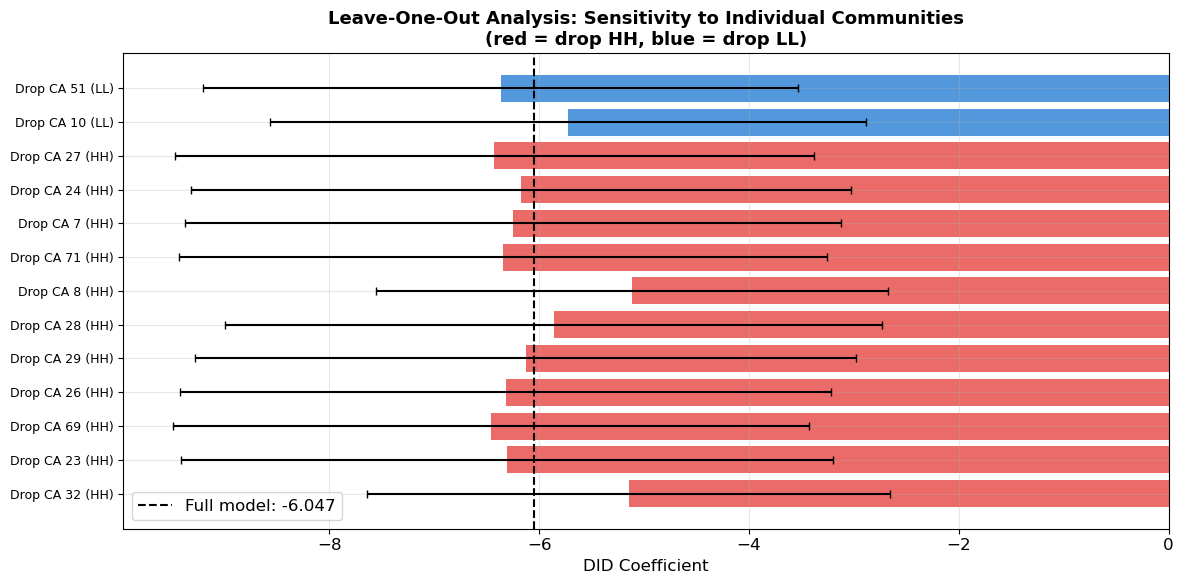

Leave-one-out coefficient range: [-6.457, -5.114]
Range: 1.343
Full model: -6.047
Max deviation: 0.933
Most influential community: CA 8 (HH)


In [8]:
# 7. Leave-One-Out Analysis

# For the LISA grouping, remove one community at a time and re-run DID.
# If the coefficient changes dramatically when one community is removed, it means the result depends on that single community.

hh_list = list(hh_cas)
ll_list = list(ll_cas)
all_communities = hh_list + ll_list

loo_results = []

for leave_out in all_communities:
    remaining_high = [c for c in hh_list if c != leave_out]
    remaining_low = [c for c in ll_list if c != leave_out]

    if len(remaining_high) == 0 or len(remaining_low) == 0:
        continue

    loo_sample = panel[
        (panel['community_area'].isin(remaining_high + remaining_low)) &
        (panel['year'].isin([2019, 2020]))
    ].copy()

    loo_sample['post'] = (loo_sample['date'] >= '2020-03-21').astype(int)
    loo_sample['treated'] = loo_sample['community_area'].isin(remaining_high).astype(int)
    loo_sample['did'] = loo_sample['post'] * loo_sample['treated']

    try:
        mod = smf.ols(
            f'crime_total ~ post + did + {controls} + C(community_area)',
            data=loo_sample
        ).fit(cov_type='cluster', cov_kwds={'groups': loo_sample['community_area']})

        loo_results.append({
            'left_out': leave_out,
            'group': 'HH' if leave_out in hh_list else 'LL',
            'coef': mod.params['did'],
            'se': mod.bse['did'],
            'p': mod.pvalues['did'],
            'n_high': len(remaining_high),
            'n_low': len(remaining_low),
        })
    except:
        pass

loo_df = pd.DataFrame(loo_results)

fig, ax = plt.subplots(figsize=(12, 6))

colors_loo = ['#E53935' if g == 'HH' else '#1976D2' for g in loo_df['group']]
ax.barh(range(len(loo_df)), loo_df['coef'], xerr=1.96*loo_df['se'],
        color=colors_loo, capsize=3, alpha=0.75)

# Reference line: full model coefficient
full_coef = results_df[(results_df['grouping'] == 'LISA HH vs LL') &
                        (results_df['y_var'] == 'crime_total')]['coef'].values[0]
ax.axvline(full_coef, color='black', ls='--', lw=1.5, label=f'Full model: {full_coef:+.3f}')
ax.axvline(0, color='gray', lw=0.5)

labels_loo = [f"Drop CA {r['left_out']} ({r['group']})" for _, r in loo_df.iterrows()]
ax.set_yticks(range(len(loo_df)))
ax.set_yticklabels(labels_loo, fontsize=9)
ax.set_xlabel('DID Coefficient')
ax.set_title('Leave-One-Out Analysis: Sensitivity to Individual Communities\n'
             '(red = drop HH, blue = drop LL)',
             fontsize=13, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '03_leave_one_out.png'), dpi=150, bbox_inches='tight')
plt.show()

coef_range = loo_df['coef'].max() - loo_df['coef'].min()
print(f"Leave-one-out coefficient range: [{loo_df['coef'].min():+.3f}, {loo_df['coef'].max():+.3f}]")
print(f"Range: {coef_range:.3f}")
print(f"Full model: {full_coef:+.3f}")
print(f"Max deviation: {max(abs(loo_df['coef'] - full_coef)):.3f}")

most_influential = loo_df.loc[(loo_df['coef'] - full_coef).abs().idxmax()]
print(f"Most influential community: CA {most_influential['left_out']} ({most_influential['group']})")


In [9]:
# 8. Summary

print("=" * 70)
print("SENSITIVITY ANALYSIS SUMMARY")
print("=" * 70)

print(f"\n1. TOTAL CRIME DID ACROSS 7 GROUPINGS:")
for _, r in total_crime.sort_values('n_high').iterrows():
    sig = '***' if r['p']<0.001 else ('**' if r['p']<0.01 else ('*' if r['p']<0.05 else ''))
    print(f"   {r['grouping']:<23s} {r['coef']:>+8.3f} (p={r['p']:.4f}) {sig}  [H={r['n_high']:.0f}, L={r['n_low']:.0f}]")

# Count how many groupings show significant negative DID for each crime type
print(f"\n2. SIGNIFICANCE CONSISTENCY (out of 7 groupings):")
for y_col, y_label in y_variables:
    sub = results_df[results_df['y_var'] == y_col]
    n_sig_neg = ((sub['p'] < 0.05) & (sub['coef'] < 0)).sum()
    n_sig_pos = ((sub['p'] < 0.05) & (sub['coef'] > 0)).sum()
    n_ns = (sub['p'] >= 0.05).sum()
    direction = 'DECREASE' if n_sig_neg >= 4 else ('INCREASE' if n_sig_pos >= 4 else 'MIXED/NS')
    print(f"   {y_label:<20s} sig- = {n_sig_neg}  sig+ = {n_sig_pos}  NS = {n_ns}  => {direction}")

print(f"\n3. CONTINUOUS INTENSITY (no binary split, all 77 CAs):")
ct_total = [r for r in cont_results if r['y_label'] == 'Total Crime'][0]
print(f"   β(Post×Intensity) = {ct_total['coef']:+.4f} (p={ct_total['p']:.4f})")

print(f"\n4. PLACEBO TESTS:")
print(f"   Pass rate: {n_pass}/{n_total}")
for _, r in placebo_df.iterrows():
    print(f"   {r['grouping']:<23s} {'PASS' if r['pass'] else 'FAIL':>6s} (p={r['p']:.4f})")

print(f"\n5. LEAVE-ONE-OUT:")
print(f"   Coefficient range: [{loo_df['coef'].min():+.3f}, {loo_df['coef'].max():+.3f}]")
print(f"   Most influential: CA {most_influential['left_out']}")

print(f"\n6. FIGURES: {FIGURE_DIR}/")
print(f"   01_sensitivity_total_crime.png")
print(f"   02_sensitivity_heatmap.png")
print(f"   03_leave_one_out.png")


SENSITIVITY ANALYSIS SUMMARY

1. TOTAL CRIME DID ACROSS 7 GROUPINGS:
   Top 10% vs Bot 10%        -7.650 (p=0.0000) ***  [H=8, L=8]
   Top 10% vs Mid 80%        -6.303 (p=0.0003) ***  [H=8, L=61]
   LISA HH vs LL             -6.047 (p=0.0000) ***  [H=11, L=2]
   Top 20% vs Bot 20%        -5.272 (p=0.0000) ***  [H=16, L=16]
   Top 25% vs Bot 25%        -4.648 (p=0.0000) ***  [H=20, L=20]
   Top 33% vs Bot 33%        -3.949 (p=0.0000) ***  [H=26, L=26]
   Median Split              -2.788 (p=0.0000) ***  [H=39, L=38]

2. SIGNIFICANCE CONSISTENCY (out of 7 groupings):
   Total Crime          sig- = 7  sig+ = 0  NS = 0  => DECREASE
   Violent Crime        sig- = 7  sig+ = 0  NS = 0  => DECREASE
   Property Crime       sig- = 7  sig+ = 0  NS = 0  => DECREASE
   Theft                sig- = 7  sig+ = 0  NS = 0  => DECREASE
   Battery              sig- = 7  sig+ = 0  NS = 0  => DECREASE
   Homicide             sig- = 0  sig+ = 6  NS = 1  => INCREASE
   Burglary             sig- = 0  sig+ = 0  N